In [1]:
import numpy as np
import jax
import jax.numpy as jnp

jax.config.update("jax_platform_name", "cpu")
from jax import vmap, jit
import matplotlib.pyplot as plt
import joblib
from qdots_qll.models import game
from qdots_qll import all_funcs
import seaborn as sns
import pandas as pd
import scipy
from functools import reduce
import os
import re
from scipy.stats import binned_statistic

import seaborn as sns


import matplotlib.font_manager as font_manager

import equinox as eqx

# from matplotlib import rcParams
from scipy.stats import binned_statistic


font = {"family": "Inter"}  # , 'weight': 'normal', 'size': 12}

# Aplica la fuente definida a Matplotlib
plt.rc("font", **font)

sns.set_palette("colorblind")

In [2]:
names_true = [
    "$\\gamma ( - \\eta)$",
    "$\\gamma ( + \\eta)$",
    "$S ( - \\eta)$",
    "$S ( +\\eta)$",
]
# names_hat = [
#     "$\\hat{\\gamma} ( + \\eta)$",
#     "$\\hat{S} ( - \\eta)$",
#     "$\\hat{S} ( +\\eta)$",
# ]

In [3]:
def compute_mean_one_run(cum_times_i, cov_arr_i, limites_bins):
    indices_bins = np.digitize(cum_times_i, limites_bins)
    means = np.array(
        [
            np.nanmean(cov_arr_i[indices_bins == i], axis=0)
            for i in range(1, len(limites_bins))
        ]
    )

    std_devs = np.array(
        [
            np.nanstd(cov_arr_i[indices_bins == i], axis=0)
            for i in range(1, len(limites_bins))
        ]
    )
    return means, std_devs


def get_binned_results_from_runs(
    times_array,
    cov_array,
    est_array,
    bin_step,
):
    dims_cov = cov_array[:, 1:].shape[2:]
    dims_est = est_array[:, 1:].shape[2:]

    cum_times = np.array(times_array[:, 1:]).cumsum(axis=1)
    cum_times_flatten = cum_times.flatten()
    cov_flatten = np.array(cov_array[:, 1:]).reshape(-1, *dims_cov)
    est_flatten = np.array(est_array[:, 1:]).reshape(-1, *dims_est)

    bins = np.arange(
        cum_times_flatten.min(), cum_times_flatten.max() + 1, bin_step
    )

    cov_mean_list = []
    cov_std_list = []

    for i in range(dims_cov[0]):
        cov_mean_row_list = []
        cov_std_row_list = []

        for j in range(dims_cov[1]):

            cov_mean_row_list.append(
                binned_statistic(
                    cum_times_flatten,
                    cov_flatten[:, i, j],
                    statistic="mean",
                    bins=bins,
                )[0]
            )
            cov_std_row_list.append(
                binned_statistic(
                    cum_times_flatten,
                    cov_flatten[:, i, j],
                    statistic="std",
                    bins=bins,
                )[0]
            )
        cov_mean_list.append(cov_mean_row_list)
        cov_std_list.append(cov_std_row_list)
    cov_mean_list = np.array(cov_mean_list).transpose(2, 1, 0)
    cov_std_list = np.array(cov_std_list).transpose(2, 1, 0)

    est_mean_list = []
    est_std_list = []

    for i in range(dims_est[0]):

        est_mean_list.append(
            binned_statistic(
                cum_times_flatten,
                est_flatten[
                    :,
                    i,
                ],
                statistic="mean",
                bins=bins,
            )[0]
        )
        est_std_list.append(
            binned_statistic(
                cum_times_flatten,
                est_flatten[
                    :,
                    i,
                ],
                statistic="std",
                bins=bins,
            )[0]
        )
    est_mean_list = np.array(est_mean_list).transpose(1, 0)
    est_std_list = np.array(est_std_list).transpose(1, 0)

    cum_times_binned, _, _ = binned_statistic(
        cum_times_flatten, cum_times_flatten, statistic="mean", bins=bins
    )
    return (
        cum_times_binned,
        cov_mean_list,
        cov_std_list,
        est_mean_list,
        est_std_list,
    )

In [115]:
def results_bin_single_run(times, covs, ests, no_bins):

    cum_times = np.array(times[1:]).cumsum()
    # bins = np.linspace(cum_times.min(), cum_times.max() + 1, no_bins)
    dims_cov = covs.shape[-2:]
    dims_est = ests.shape[-1:]

    cov_mean_list = []
    cov_std_list = []

    for i in range(dims_cov[0]):
        cov_mean_row_list = []
        cov_std_row_list = []

        for j in range(dims_cov[1]):

            cov_mean_row_list.append(
                binned_statistic(
                    cum_times,
                    covs[1:, i, j],
                    statistic="mean",
                    bins=no_bins,
                )[0]
            )
            cov_std_row_list.append(
                binned_statistic(
                    cum_times,
                    covs[1:, i, j],
                    statistic="std",
                    bins=no_bins,
                )[0]
            )
        cov_mean_list.append(cov_mean_row_list)
        cov_std_list.append(cov_std_row_list)
    cov_mean_list = np.array(cov_mean_list).transpose(2, 1, 0)
    cov_std_list = np.array(cov_std_list).transpose(2, 1, 0)

    est_mean_list = []
    est_std_list = []

    for i in range(dims_est[0]):

        est_mean_list.append(
            binned_statistic(
                cum_times,
                ests[
                    1:,
                    i,
                ],
                statistic="mean",
                bins=no_bins,
            )[0]
        )
        est_std_list.append(
            binned_statistic(
                cum_times,
                ests[
                    1:,
                    i,
                ],
                statistic="std",
                bins=no_bins,
            )[0]
        )
    est_mean_list = np.array(est_mean_list).transpose(1, 0)
    est_std_list = np.array(est_std_list).transpose(1, 0)

    cum_times_binned, _, _ = binned_statistic(
        cum_times, cum_times, statistic="mean", bins=no_bins
    )
    times_binned, _, _ = binned_statistic(
        cum_times, np.array(times[1:]), statistic="median", bins=no_bins
    )
    return (
        times_binned,
        cum_times_binned,
        cov_mean_list,
        cov_std_list,
        est_mean_list,
        est_std_list,
    )

In [116]:
from qdots_qll.models import game


model = joblib.load("../results/run_2024-01-22_20:29:42_model.job")
true_parameters = game.true_pars
number_of_samples = 500

In [209]:
job_filenames = [
    "../results/run_2024-01-17_11:07:58_results.job",
    "../results/run_2024-01-16_18:42:07_results.job",
    "../results/run_2024-01-22_20:29:42_results.job",
]
# filenames = ["../results_cluster/one_qdot/" + i for i in filenames]
# job_filenames = list(filter(re.compile(".*job").match, filenames))
# log_filenames = list(filter(re.compile(".*log").match, filenames))

runs = [joblib.load(i) for i in job_filenames]

In [210]:
runs[0].times_array.shape

(500, 4000)

In [211]:
legend_array = [
    "Random",
    "Max norm(FIM)",
    "Max det(FIM)",
]

<Axes: ylabel='Count'>

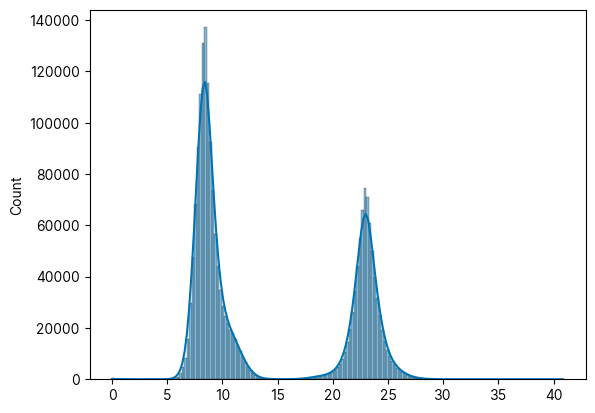

In [212]:
sns.histplot(np.array(runs[2].times_array).flatten(), kde=True)

In [121]:
run.iteration.shape[0]

500

In [213]:
results_binned = []

no_bins = 1500
for i in range(len(runs)):
    run = runs[i]

    times_list = []
    cumtimes_list = []
    covmean_list = []
    covstd_list = []
    estmean_list = []
    eststd_list = []

    no_runs = run.iteration.shape[0]
    for k in range(no_runs):
        covs = run.cov_array[k]
        ests = run.estimates_array[k]
        times = run.times_array[k]

        re = results_bin_single_run(times, covs, ests, no_bins)

        times_list.append(re[0])
        cumtimes_list.append(re[1])
        covmean_list.append(re[2])
        covstd_list.append(re[3])
        estmean_list.append(re[4])
        eststd_list.append(re[5])

    times_list = np.mean(np.array(times_list), axis=0)
    cumtimes_list = np.array(cumtimes_list).mean(axis=0)
    covstd_list = np.array(covmean_list).std(axis=0)
    covmean_list = np.array(covmean_list).mean(axis=0)

    # covstd_list = np.array(covstd_list).mean(axis=0)

    eststd_list = np.array(estmean_list).std(axis=0)
    estmean_list = np.array(estmean_list).mean(axis=0)

    # eststd_list = np.array(eststd_list).mean(axis=0)

    # (
    #     cum_times_binned,
    #     cov_mean_list,
    #     cov_std_list,
    #     est_mean_list,
    #     est_std_list,
    # ) = get_binned_results_from_runs(
    #     runs[i].times_array, runs[i].cov_array, runs[i].estimates_array, 1000
    # )

    cov_dict = {
        "times": times_list,
        "cumtimes": cumtimes_list,
        "covmean": covmean_list,
        "covstd": covstd_list,
        "estmean": estmean_list,
        "eststd": eststd_list,
    }
    results_binned.append(cov_dict)


# for i in range(len(results_binned)):
#     times = results_binned[i]["times"]
#     # times = np.diff(cumtimes, prepend=0)
#     covmeans = results_binned[i]["covmean"]
#     estmeans = results_binned[i]["estmean"]

#     fisher_information_each_time = np.array(
#         jax.vmap(
#             lambda particle, time: m.fim(particle, time, ground_state_qdot),
#             in_axes=(0, 0),
#         )(estmeans, times)
#     )

#     det_fisher_information_each_time = np.array(
#         jax.vmap(lambda f: jnp.linalg.det(f))(fisher_information_each_time)
#     )

#     results_binned[i]["fishermeans"] = fisher_information_each_time
#     results_binned[i]["fisherdets"] = det_fisher_information_each_time

#     det_covs = np.array(jax.vmap(lambda f: jnp.linalg.det(f))(covmeans))
#     results_binned[i]["covdet"] = det_covs

In [214]:
# results_binned[2]["times"] = np.median(
#     np.array(runs[2].times_array.flatten())
# ) * np.ones(results_binned[2]["times"].shape)

for i in range(len(results_binned)):
    times = results_binned[i]["times"]
    # times = np.diff(cumtimes, prepend=0)
    covmeans = results_binned[i]["covmean"]
    estmeans = results_binned[i]["estmean"]

    fisher_information_each_time = np.array(
        jax.vmap(
            lambda particle, time: model.fim(
                particle,
                time,
            ),
            in_axes=(0, 0),
        )(estmeans, times)
    )

    det_fisher_information_each_time = np.array(
        jax.vmap(lambda f: jnp.linalg.det(f))(fisher_information_each_time)
    )

    results_binned[i]["fishermeans"] = fisher_information_each_time
    results_binned[i]["fisherdets"] = det_fisher_information_each_time

    det_covs = np.array(jax.vmap(lambda f: jnp.linalg.det(f))(covmeans))
    results_binned[i]["covdet"] = det_covs

In [ ]:
# i = 1
# j = 2

# fig, axs = plt.subplots(2, 2, figsize=(10, 10), dpi=200)

# for j, ax in enumerate(axs.flatten()):
#     for i in range(3):
#         ax.plot(
#             results_binned[i]["cumtimes"],
#             results_binned[i]["covmean"][:, j, j], '-.'
#         )
#         ax.fill_between(
#             x=results_binned[i]["cumtimes"],
#             y1=results_binned[i]["covmean"][:, j, j]
#             + results_binned[i]["covstd"][:, j, j],
#             y2=results_binned[i]["covmean"][:, j, j]
#             - results_binned[i]["covstd"][:, j, j],
#             alpha=0.3,
#         )
#         ax.loglog()

In [196]:
names_true

['$\\gamma ( - \\eta)$',
 '$\\gamma ( + \\eta)$',
 '$S ( - \\eta)$',
 '$S ( +\\eta)$']

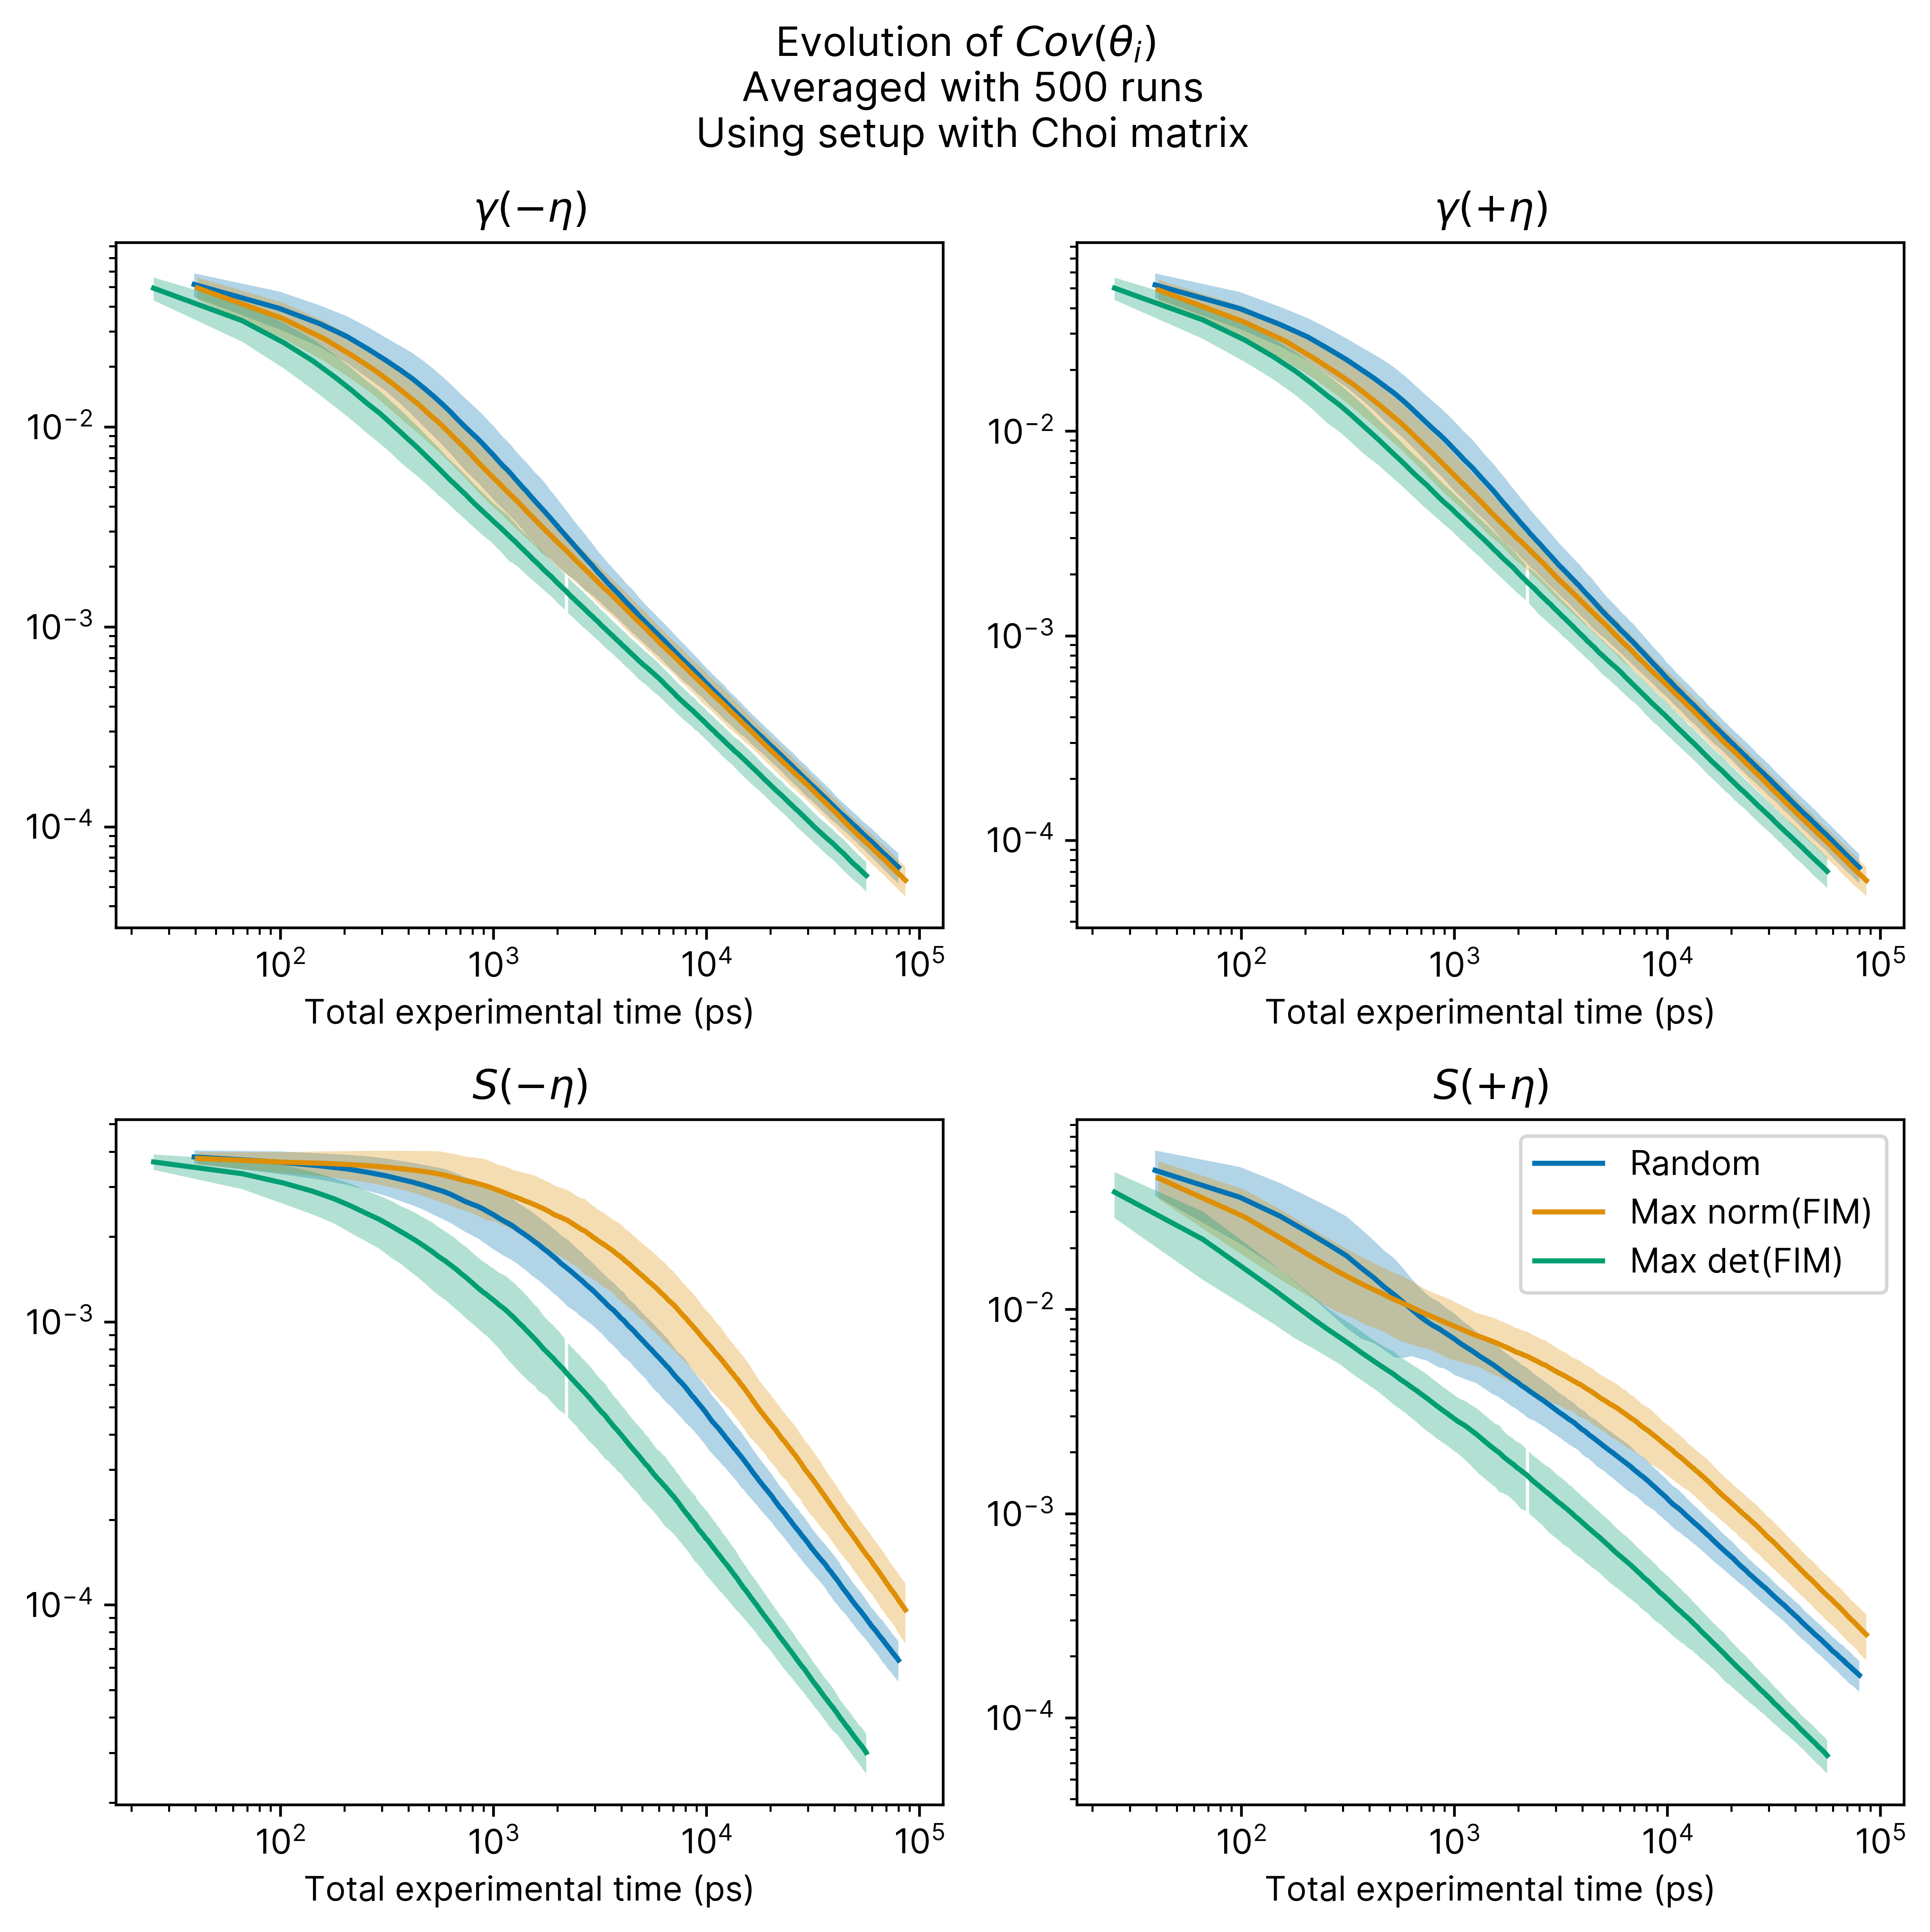

In [243]:
i = 1
j = 2

fig, axs = plt.subplots(2, 2, figsize=(8, 8), dpi=600)

for j, ax in enumerate(axs.flatten()):
    for i in range(3):
        ax.set_xlabel("Total experimental time (ps)")
        ax.plot(
            results_binned[i]["cumtimes"],
            results_binned[i]["covmean"][:, j, j],
            "-",
            label=legend_array[i],
        )
        ax.fill_between(
            x=results_binned[i]["cumtimes"],
            y1=results_binned[i]["covmean"][:, j, j]
            + results_binned[i]["covstd"][:, j, j],
            y2=results_binned[i]["covmean"][:, j, j]
            - results_binned[i]["covstd"][:, j, j],
            alpha=0.3,
        )
        ax.set_title(names_true[j])
        ax.loglog()
ax.legend()
fig.suptitle(
    "Evolution of $Cov(\\theta_i)$ \n Averaged with 500 runs\n Using setup with Choi matrix"
)
plt.tight_layout()
plt.show()

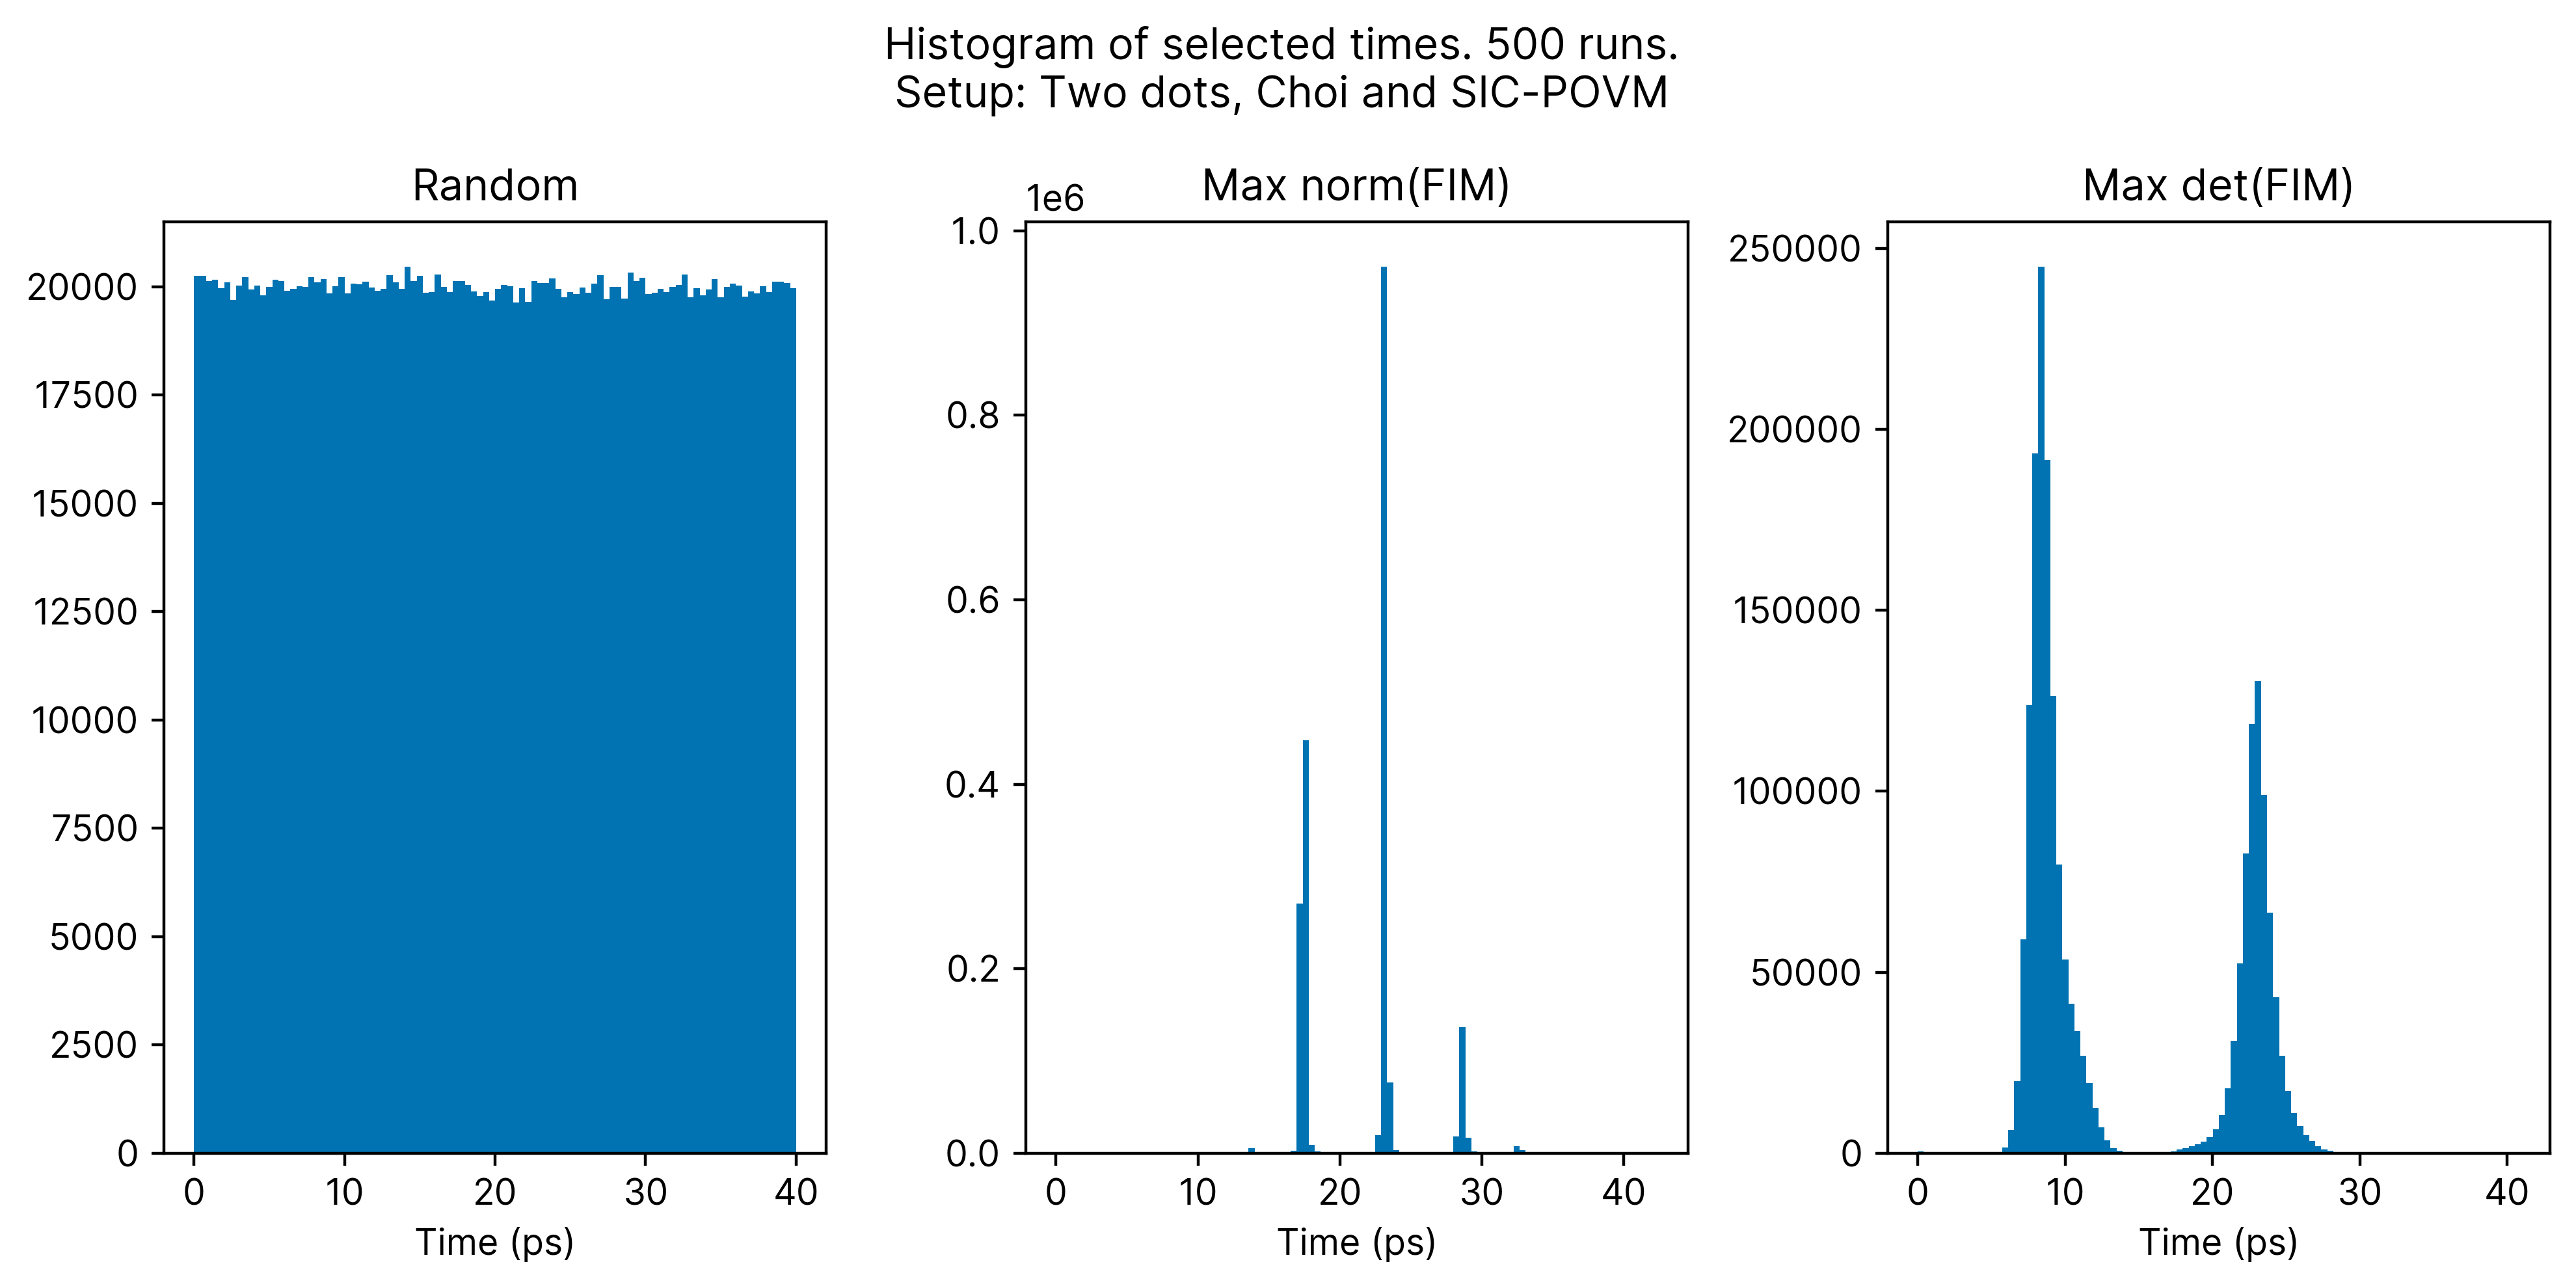

In [241]:
fig, axs = plt.subplots(1, 3, figsize=(10, 5), dpi=400)


for j, ax in enumerate(axs.flatten()):
    run = runs[j]
    ax.hist(np.array(run.times_array).flatten(), bins=100)
    ax.set_title(legend_array[j])
    ax.set_xlabel("Time (ps)")


fig.suptitle(f"Histogram of selected times. 500 runs. \nSetup: Two dots, Choi and SIC-POVM ")
plt.tight_layout()
plt.show()

In [49]:
import scipy.stats

In [221]:
m = model
ts = np.linspace(0, 60, 500)
det_fim_truetimes = jax.vmap(
    lambda t: jnp.linalg.det(m.fim(true_parameters, t))
)(ts)
best_t = ts[1:][np.argmax(det_fim_truetimes[1:])]

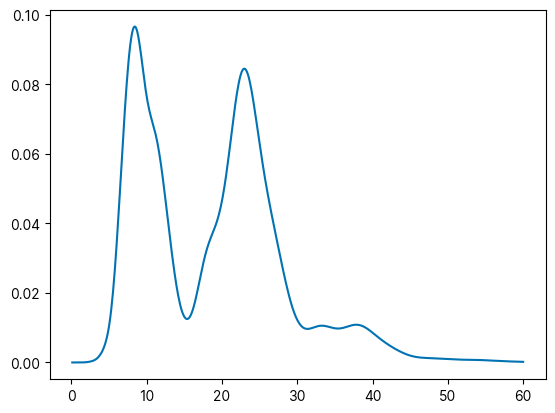

In [222]:
plt.plot(ts, det_fim_truetimes)

In [187]:
# best_t =  scipy.stats.mode(np.array(runs[2].times_array[:, 1:].flatten()))[0]
true_inv_FIM = jnp.linalg.inv(m.fim(true_parameters, best_t))
true_FIM = m.fim(
    true_parameters,
    best_t,
)

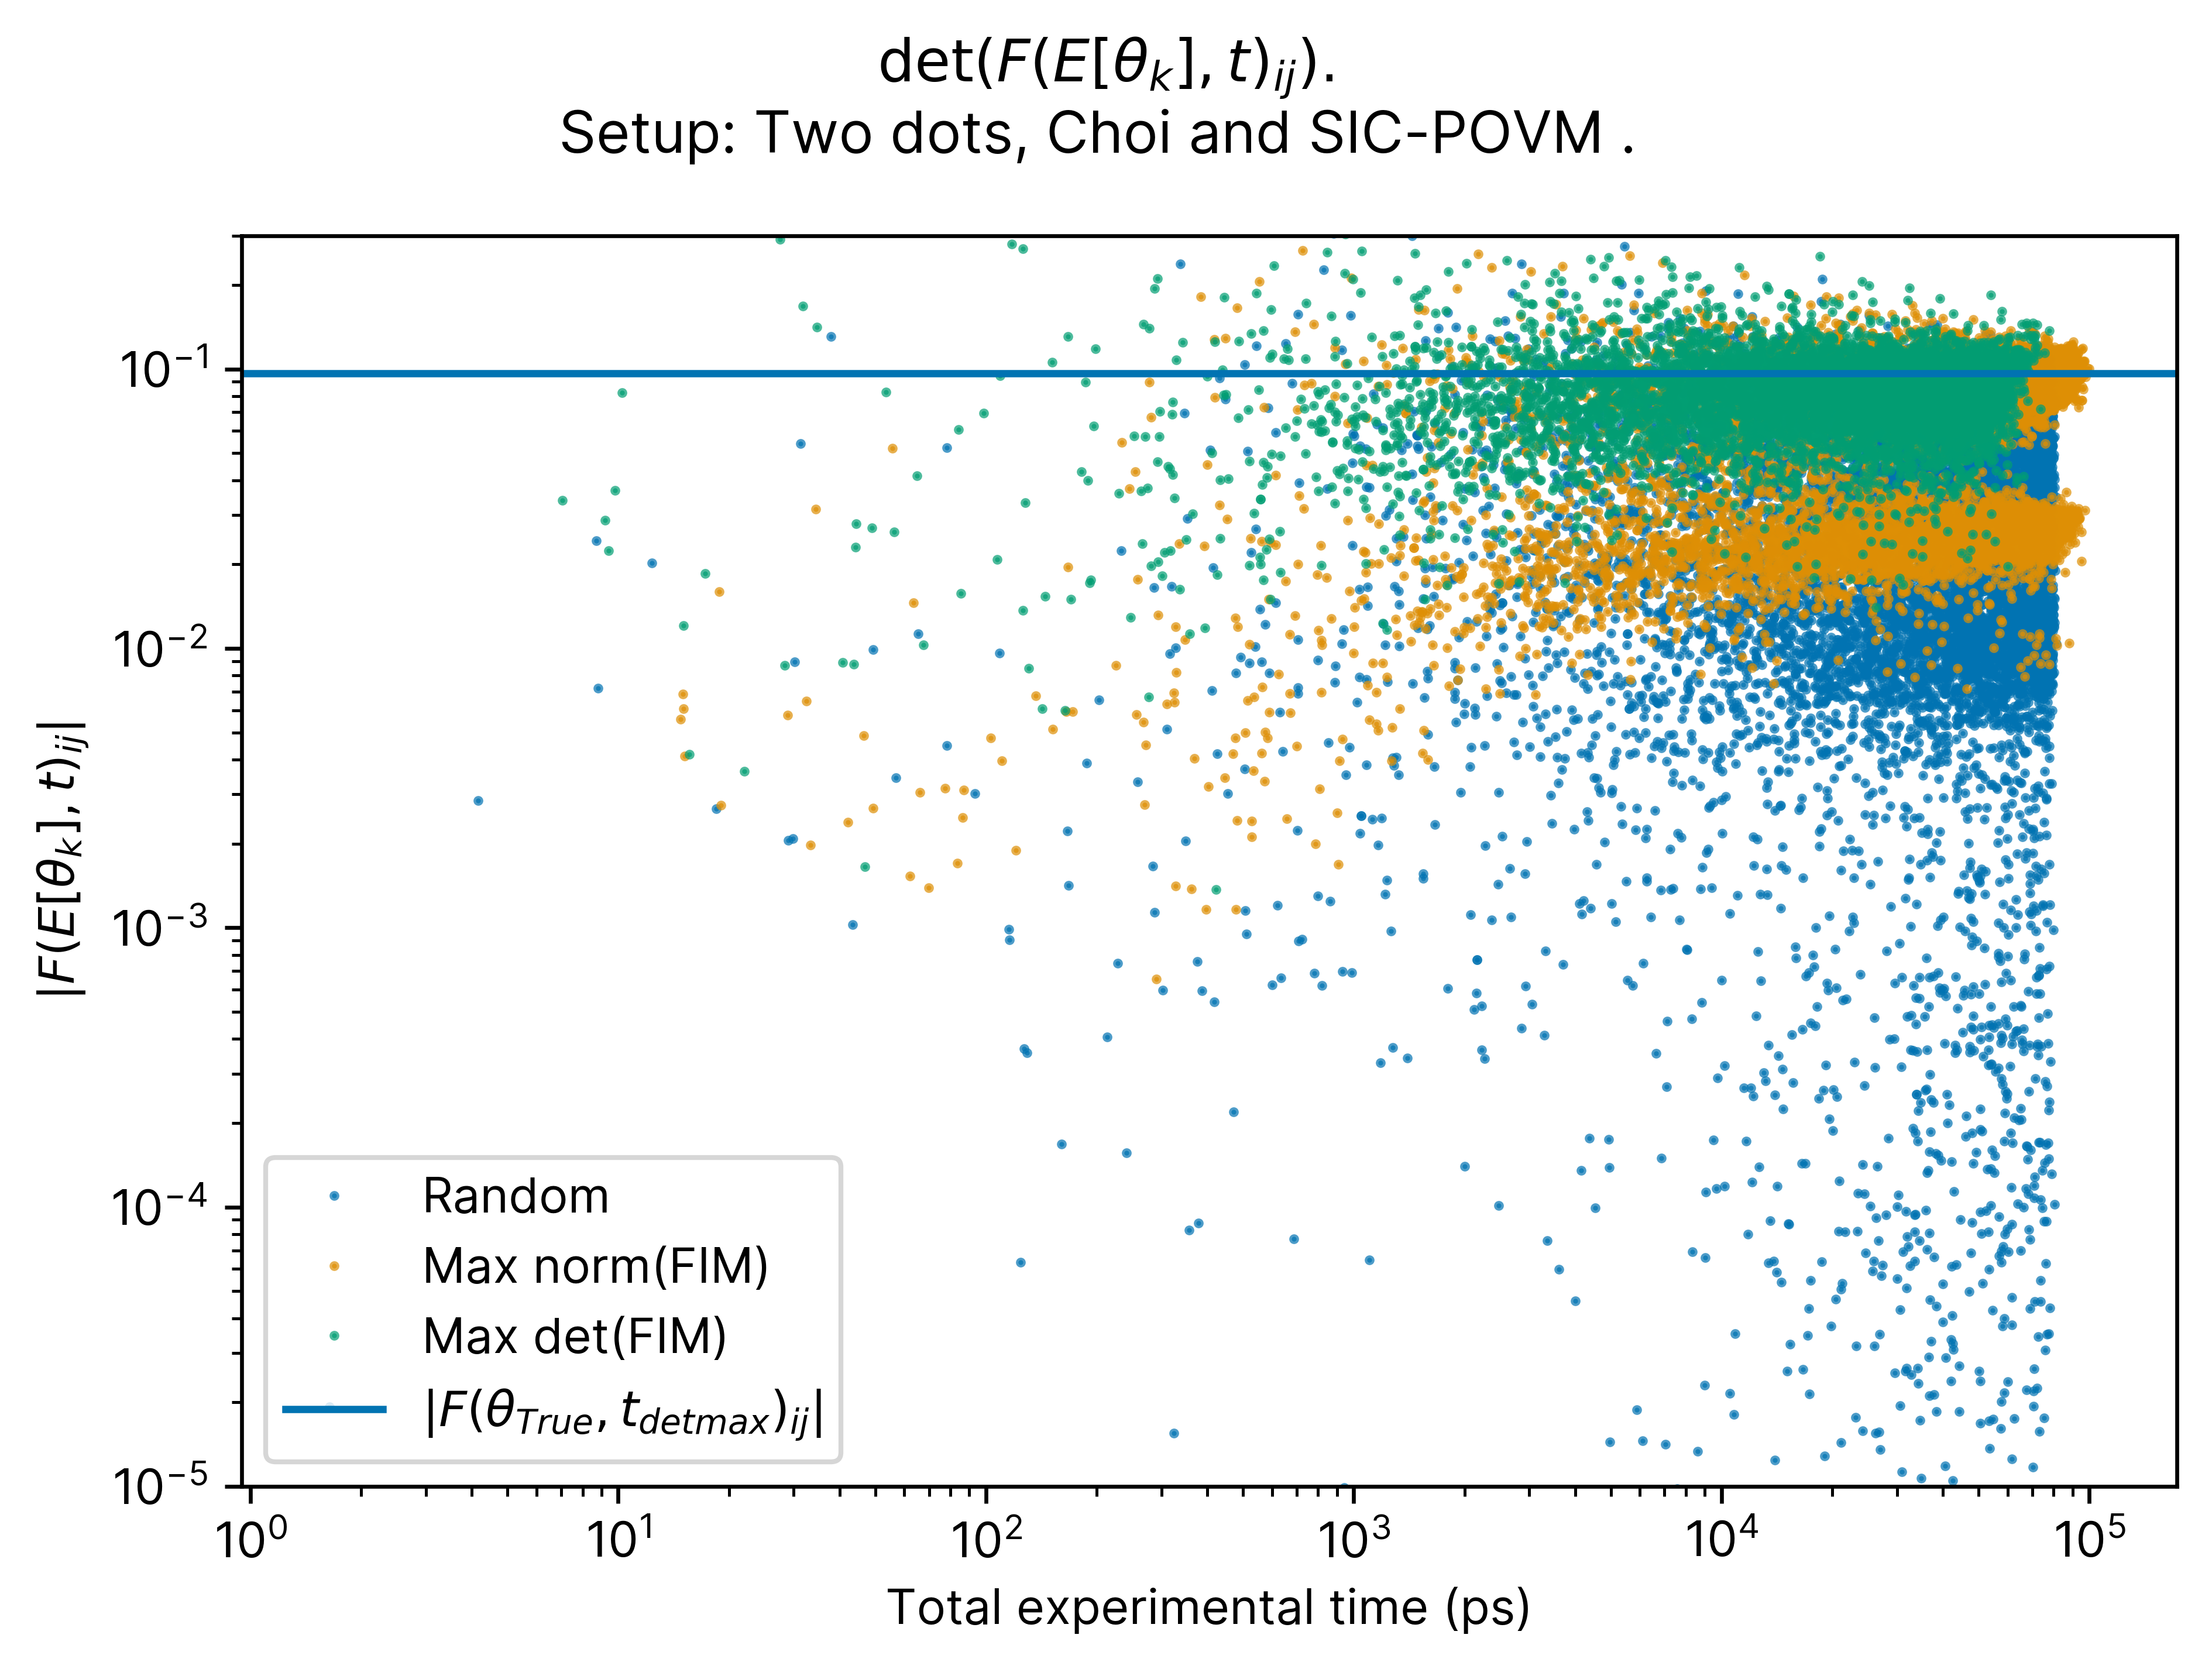

In [248]:
fig, ax = plt.subplots(dpi=600)
for i in range(3):
    # i = 1
    # print(legend_array[i])
    ax.plot(
        results_binned[i]["cgcumtimes"],
        results_binned[i]["fisherdets"],
        ".",
        label=legend_array[i],
        ms=2,
        alpha=0.7,
    )
ax.axhline(
    jnp.linalg.det(true_FIM),
    label="$|F( \\theta_{True}, t_{det max})_{ij} | $",
)
ax.legend()
ax.set_ylim(1e-5, 0.3)
ax.loglog()

ax.set_xlabel("Total experimental time (ps)")
ax.set_ylabel("$|F( E[\\theta_k], t)_{ij} | $")
fig.suptitle(
    " $\\operatorname{det} (F( E[\\theta_k], t)_{ij} ). $ \nSetup: Two dots, Choi and SIC-POVM . "
)
plt.tight_layout()
plt.show()

In [159]:
run.times_array.cumsum(axis=1).flatten()

Array([0.0000000e+00, 1.2928846e+01, 2.0755135e+01, ..., 5.3186109e+04,
       5.3205895e+04, 5.3213406e+04], dtype=float32)

In [217]:
for i in range(len(results_binned)):
    run = runs[i]

    times = np.array(run.times_array).flatten()

    rng = np.random.default_rng(seed=0)

    idx = rng.choice(np.arange(len(times)), size=10000)

    ntimes = times[idx]

    nestmeans = np.array(run.estimates_array).reshape(-1, 4)[idx]

    ncumtimes = np.array(run.times_array.cumsum(axis=1).flatten())[idx]

    ord_idx = np.argsort(ncumtimes)

    ncumtimes = ncumtimes[ord_idx]
    ntimes = ntimes[ord_idx]
    nestmeans = nestmeans[ord_idx]

    fisher_information_each_time = np.array(
        jax.vmap(
            lambda particle, time: model.fim(
                particle,
                time,
            ),
            in_axes=(0, 0),
        )(nestmeans, ntimes)
    )

    det_fisher_information_each_time = np.array(
        jax.vmap(lambda f: jnp.linalg.det(f))(fisher_information_each_time)
    )

    results_binned[i]["fishermeans"] = fisher_information_each_time
    results_binned[i]["fisherdets"] = det_fisher_information_each_time

    det_covs = np.array(jax.vmap(lambda f: jnp.linalg.det(f))(covmeans))
    results_binned[i]["covdet"] = det_covs

    results_binned[i]["cgcumtimes"] = ncumtimes


# times =
# for i in range(len(results_binned)):
#     times = results_binned[i]["times"]
#     # times = np.diff(cumtimes, prepend=0)
#     covmeans = results_binned[i]["covmean"]
#     estmeans = results_binned[i]["estmean"]

#     fisher_information_each_time = np.array(
#         jax.vmap(
#             lambda particle, time: model.fim(
#                 particle,
#                 time,
#             ),
#             in_axes=(0, 0),
#         )(estmeans, times)
#     )

#     det_fisher_information_each_time = np.array(
#         jax.vmap(lambda f: jnp.linalg.det(f))(fisher_information_each_time)
#     )

#     results_binned[i]["fishermeans"] = fisher_information_each_time
#     results_binned[i]["fisherdets"] = det_fisher_information_each_time

#     det_covs = np.array(jax.vmap(lambda f: jnp.linalg.det(f))(covmeans))
#     results_binned[i]["covdet"] = det_covs

In [244]:
# Plot of mse

In [ ]:
# for j, ax in enumerate(axs.flatten()):
#     for i in range(3):
#         ax.set_xlabel("Total experimental time (ps)")
#         ax.plot(
#             results_binned[i]["cumtimes"],
#             results_binned[i]["covmean"][:, j, j],
#             "-",
#             label=legend_array[i],
#         )
#         ax.fill_between(
#             x=results_binned[i]["cumtimes"],
#             y1=results_binned[i]["covmean"][:, j, j]
#             + results_binned[i]["covstd"][:, j, j],
#             y2=results_binned[i]["covmean"][:, j, j]
#             - results_binned[i]["covstd"][:, j, j],
#             alpha=0.3,
#         )
#         ax.set_title(names_true[j])
#         ax.loglog()
# ax.legend()
# fig.suptitle(
#     "Evolution of $Cov(\\theta_i)$ \n Averaged with 500 runs\n Using setup with Choi matrix"
# )
# plt.tight_layout()
# plt.show()